In [190]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('netflix1.csv')
df = pd.read_csv('netflix1.csv', parse_dates=["date_added"])
df.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [42]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8790 non-null   str           
 1   type          8790 non-null   str           
 2   title         8790 non-null   str           
 3   director      8790 non-null   str           
 4   country       8790 non-null   str           
 5   date_added    8790 non-null   datetime64[us]
 6   release_year  8790 non-null   int64         
 7   rating        8790 non-null   str           
 8   duration      8790 non-null   str           
 9   listed_in     8790 non-null   str           
dtypes: datetime64[us](1), int64(1), str(8)
memory usage: 686.8 KB


In [43]:
df.shape

(8790, 10)

In [44]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64

In [45]:
df.duplicated().sum()

np.int64(0)

In [46]:
bad_values = [
    "not given", "unknown", "n/a", "na", "none",
    "null", "missing", "-", "--", "?"
]

for col in df.select_dtypes(include=["object", "string"]).columns:
    temp = df[col].astype(str).str.strip().str.lower()
    count = temp.isin(bad_values).sum()
    
    if count > 0:
        print(col, count)


title 1
director 2588
country 287


In [117]:
for col in df.select_dtypes(include=["object", "string"]).columns:
    temp = df[col].astype(str).str.strip()
    mask = temp.str.lower().isin(bad_values)
    df.loc[mask, col] = np.nan

df.isna().sum() 

show_id            0
type               0
title              1
director        2588
country          287
date_added         0
release_year       0
rating             0
duration           0
listed_in          0
dtype: int64

In [120]:
df = df.dropna(subset=["title"])

df["director"] = df["director"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")

df.isna().sum() 

show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64

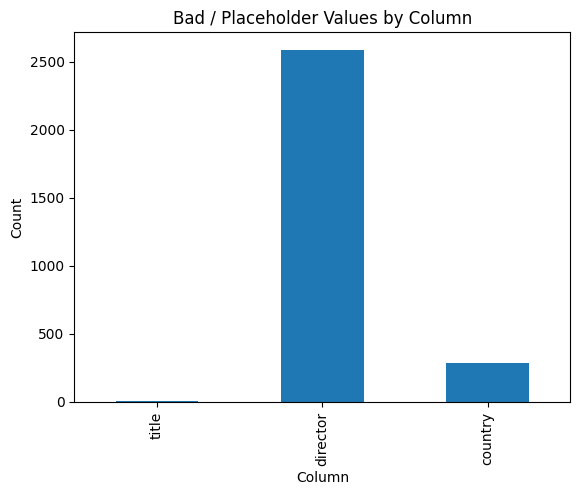

In [169]:
bad_counts.plot(kind="bar")

plt.title("Bad / Placeholder Values by Column")
plt.xlabel("Column")
plt.ylabel("Count")
plt.show()


In [189]:
df.describe()

,date_added,release_year
count,8789,8789.000000
mean,2019-05-17 20:06:41.410854,2014.183525
min,2008-01-01 00:00:00,1925.000000
25%,2018-04-06 00:00:00,2013.000000
50%,2019-07-03 00:00:00,2017.000000
75%,2020-08-19 00:00:00,2019.000000
max,2021-09-25 00:00:00,2021.000000
std,NaN,8.825903


In [171]:
df["rating"].unique()

<StringArray>
[   'PG-13',    'TV-MA',    'TV-PG',    'TV-14',    'TV-Y7',     'TV-Y',
       'PG',     'TV-G',        'R',        'G',    'NC-17',       'NR',
 'TV-Y7-FV',       'UR']
Length: 14, dtype: str

In [172]:
df["rating"].value_counts()

rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        489
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

In [173]:
df["rating"].value_counts(normalize=True) * 100

rating
TV-MA       36.466037
TV-14       24.542041
TV-PG        9.796336
R            9.090909
PG-13        5.563773
TV-Y7        3.788827
TV-Y         3.481625
PG           3.265445
TV-G         2.503129
NR           0.898851
G            0.466492
TV-Y7-FV     0.068267
NC-17        0.034134
UR           0.034134
Name: proportion, dtype: float64

In [174]:
content_by_year = (
    df.groupby(df["date_added"].dt.year)
      .size()
      .sort_index(ascending=False)
)

print(content_by_year)

date_added
2021    1497
2020    1879
2019    2016
2018    1648
2017    1185
2016     426
2015      82
2014      24
2013      11
2012       3
2011      13
2010       1
2009       2
2008       2
dtype: int64


In [175]:
df["release_year"].value_counts().sort_values(ascending=False).head()


release_year
2018    1146
2019    1030
2017    1030
2020     953
2016     901
Name: count, dtype: int64

In [176]:
genres = df["listed_in"].str.split(", ").explode()

genres.value_counts().head(10)


listed_in
International Movies        2752
Dramas                      2426
Comedies                    1674
International TV Shows      1349
Documentaries                869
Action & Adventure           858
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

In [177]:
movies = df[df["type"] == "Movie"].copy()

movies["duration_min"] = movies["duration"].str.extract(r"(\d+)").astype(float)

movies["duration_min"].mean()


np.float64(99.58269387755102)

In [178]:
tv = df[df["type"] == "TV Show"].copy()

tv["seasons"] = tv["duration"].str.extract(r"(\d+)").astype(float)

tv["seasons"].value_counts().sort_index()


seasons
1.0     1791
2.0      421
3.0      198
4.0       94
5.0       64
6.0       33
7.0       23
8.0       17
9.0        9
10.0       6
11.0       1
12.0       2
13.0       2
15.0       2
17.0       1
Name: count, dtype: int64

In [179]:
tv["seasons"].median()

np.float64(1.0)

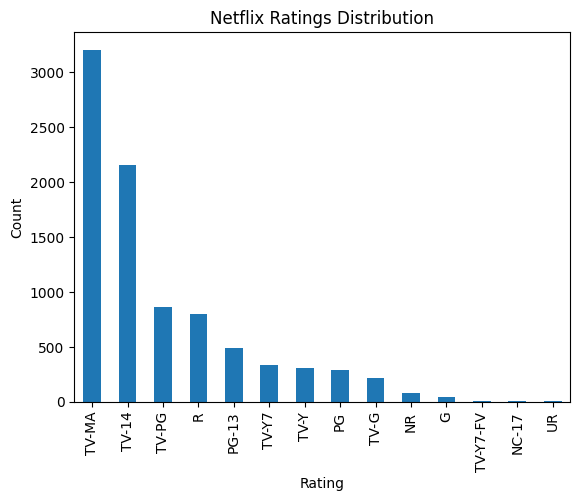

In [180]:
df["rating"].value_counts().plot(kind="bar")

plt.title("Netflix Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

In [181]:
df["type"].value_counts()

type
Movie      6125
TV Show    2664
Name: count, dtype: int64

In [182]:
df["type"].value_counts(normalize=True) * 100

type
Movie      69.689384
TV Show    30.310616
Name: proportion, dtype: float64

In [183]:
df["director"].value_counts()

director
Unknown                    2588
Rajiv Chilaka                20
Raúl Campos, Jan Suter       18
Alastair Fothergill          18
Suhas Kadav                  16
                           ... 
Mu Chu                        1
Chandra Prakash Dwivedi       1
Majid Al Ansari               1
Peter Hewitt                  1
Mozez Singh                   1
Name: count, Length: 4527, dtype: int64

In [184]:
df["director"].value_counts(normalize=True) * 100

director
Unknown                    29.445898
Rajiv Chilaka               0.227557
Raúl Campos, Jan Suter      0.204801
Alastair Fothergill         0.204801
Suhas Kadav                 0.182046
                             ...    
Mu Chu                      0.011378
Chandra Prakash Dwivedi     0.011378
Majid Al Ansari             0.011378
Peter Hewitt                0.011378
Mozez Singh                 0.011378
Name: proportion, Length: 4527, dtype: float64

In [185]:
df["country"].value_counts()

country
United States     3240
India             1057
United Kingdom     637
Pakistan           421
Unknown            287
                  ... 
Luxembourg           1
Senegal              1
Belarus              1
Puerto Rico          1
Cyprus               1
Name: count, Length: 86, dtype: int64

In [186]:
df["country"].value_counts(normalize=True) * 100

country
United States     36.864262
India             12.026397
United Kingdom     7.247696
Pakistan           4.790079
Unknown            3.265445
                    ...    
Luxembourg         0.011378
Senegal            0.011378
Belarus            0.011378
Puerto Rico        0.011378
Cyprus             0.011378
Name: proportion, Length: 86, dtype: float64